In [13]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
# from fastlisaresponse import ResponseWrapper
import tqdm
import os
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.fisher import StableEMRIFisher
from lisatools.sensitivity import get_sensitivity,CornishLISASens
import pandas as pd
try:
    import cupy as cp
    use_gpu = True
except ImportError:
    print("Not on GPU")
    use_gpu = False


use_gpu = False
if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
    force_backend = 'cpu'
else:
    force_backend = 'gpu'
    pass #let the backend decide for itself.

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,)

##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################
from pathlib import Path

Not on GPU


In [14]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable',
                      noise_model=get_sensitivity,
                      noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                      channels=["A","E"])

# First Analysis
We will keep these paramters constant.
  1. dist (float) – Luminosity distance in Gpc.
  2. qS (float) – Sky location polar angle in ecliptic coordinates.
  3. phiS (float) – Sky location azimuthal angle in ecliptic coordinates.

## Other Paramter Values Used:
1. m1 (float) – Mass of larger black hole in solar masses - 1e6
2. m2 (float) – Mass of compact object in solar masses. - 1e1
3. a (float) – Dimensionless spin of massive black hole - 0.8
4. e0: Initial eccentricity. -> 0.4
5. xI0 : Initial cosine of the inclination angle -> 1
6. dist - distance in Gpc - 0.5 Gpc
7. phiK - Initial BH spin azimuthal angle in ecliptic coordinates. - $\pi$\3
8. phi_phi0 - Initial phase for $\Phi_{\phi}$ - 0.5
9. phi_theta0 - Initial phase for $\Phi_{\theta}$ - 0.5
10. phi_r0 - Initial phase for $\Phi_{r}$ - 0.5
11. dt - 10 seconds (samplking interval)
12. T - 0.5 years (observation window)
13. chi2 = 0.8 (spin of secondary)
13. deviation paramters at kept at zero 

In [15]:
m1 = 1e6
m2 = 1e1
a = 0.9
e0 = 0.4
xI0 = 1.0
dist = 0.5
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3
Phi_phi0 = 0.5
Phi_theta0 =0.5
Phi_r0 = 0.5

dt = 10.0
T = 0.5

chi2 = 0.9

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = True
evolve_primary = False
evolve_2PA = True
deviation_included=True
p0=7

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

#param_names = ['m1','m2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',"dev0p","dev0e","dev1p","dev1e"] #works
#rhvae to take qK and phiK constant for it to run
#'Phi_phi0',"Phi_theta0",'Phi_r0' derivatives are present analytically it says

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

emri_kwargs = {"T":T, "dt":dt}

sef.SNRcalc_SEF(*pars_list_snr,**emri_kwargs)


wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.9, 7, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.5, 0.5, 0.5, 0.9, True, False, True, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)


np.float64(67.45981195792619)

T:  0.5 dt:  10.0
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.9, 7, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.5, 0.5, 0.5, 0.9, True, False, True, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 67.45981195792619
calculating stable deltas...
Gamma_ii for m1: 589.218150907682
Gamma_ii for m1: 589.2180913309171
Gamma_ii for m1: 589.2176738681455
Gamma_ii for m1: 589.2180018458505
Gamma_ii for m1: 589.218424498623
Gamma_ii for m1: 589.2183983616194
Gamma_ii for m1: 589.2171929261154
Gamma_ii for m1: 589.2176862492913
Gamma_ii for m1: 589.2169675192557
Gamma_ii for m1: 589.2204031080616
Gamma_ii for m1: 589.2132173569391
Gamma_ii for m1: 589.189927749305
Gamma_ii for m1: 589.2320363211267
Gamma_ii for m1: 589.2385030820458
Gamma_ii for m1: 589.1293054538597
Gamma_ii for m1: 589.4480510539504
Gamma_ii for m1: 589.1740700233161
Gamma_ii for m1: 589.2769484629803
Gamma_ii for m1: 588.56996317

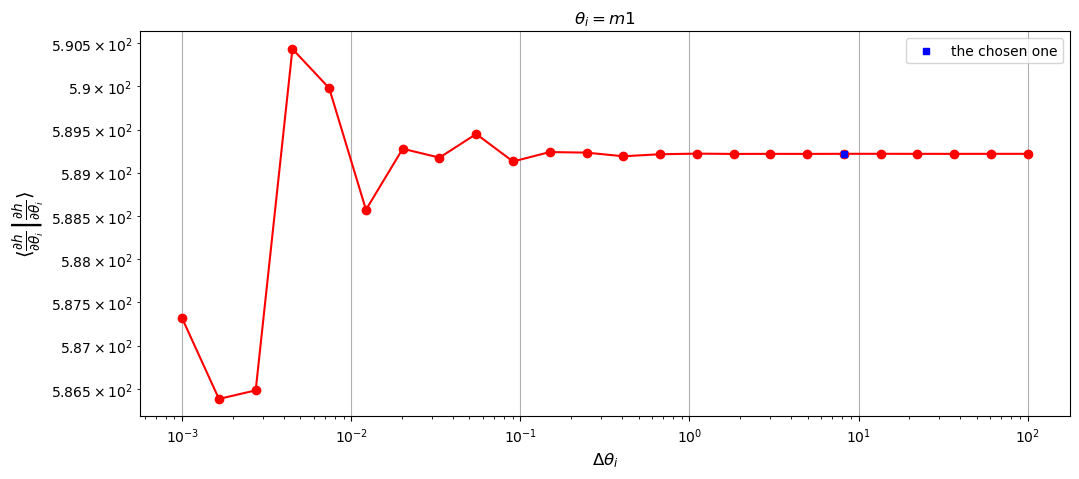

Gamma_ii for m2: 75382440910.86511
Gamma_ii for m2: 75382439544.76813
Gamma_ii for m2: 75382440908.45288
Gamma_ii for m2: 75382442022.79747
Gamma_ii for m2: 75382446454.20595
Gamma_ii for m2: 75382430707.06068
Gamma_ii for m2: 75382442024.90443
Gamma_ii for m2: 75382464707.03258
Gamma_ii for m2: 75382385187.25276
Gamma_ii for m2: 75382470530.42188
Gamma_ii for m2: 75382382651.6309
Gamma_ii for m2: 75382527962.0728
Gamma_ii for m2: 75383030155.33598
Gamma_ii for m2: 75382912002.90984
Gamma_ii for m2: 75382466081.53891
Gamma_ii for m2: 75382171716.38774
Gamma_ii for m2: 75381338904.89409
Gamma_ii for m2: 75384009449.1988
Gamma_ii for m2: 75380232562.69998
Gamma_ii for m2: 75384007135.77213
Gamma_ii for m2: 75385634950.21066
Gamma_ii for m2: 75390488120.7492
Gamma_ii for m2: 75336907990.8544
Gamma_ii for m2: 75385803514.61871
[np.float64(1.8122217762029093e-08), np.float64(1.809021752259357e-08), np.float64(1.4782548287522893e-08), np.float64(5.878568136516023e-08), np.float64(2.088967563

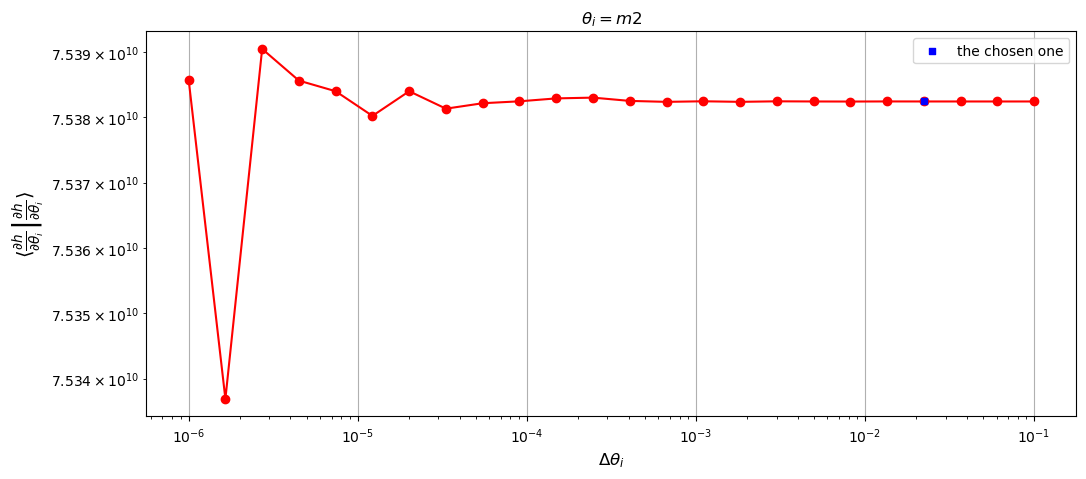

Gamma_ii for a: 6340209215106.568
Gamma_ii for a: 6340225888056.227
Gamma_ii for a: 6340234961537.535
Gamma_ii for a: 6340219631274.805
Gamma_ii for a: 6340195901866.715
Gamma_ii for a: 6340239959930.206
Gamma_ii for a: 6340263322740.473
Gamma_ii for a: 6340505403743.103
Gamma_ii for a: 6339966263374.191
Gamma_ii for a: 6340180287478.246
Gamma_ii for a: 6338921447705.667
Gamma_ii for a: 6338376698539.844
Gamma_ii for a: 6339557491709.386
Gamma_ii for a: 6346375204308.406
Gamma_ii for a: 6341504675936.212
Gamma_ii for a: 6346948720243.03
Gamma_ii for a: 6346991216726.32
Gamma_ii for a: 6353585912595.397
Gamma_ii for a: 6367094996685.929
Gamma_ii for a: 6320808376288.586
Gamma_ii for a: 6412045350013.18
Gamma_ii for a: 6253947789682.125
Gamma_ii for a: 6634997436891.205
Gamma_ii for a: 6455952805171.604
[np.float64(2.629709091218938e-06), np.float64(1.4310954347334457e-06), np.float64(2.4179387500786546e-06), np.float64(3.7426932001986263e-06), np.float64(6.948958362720381e-06), np.float

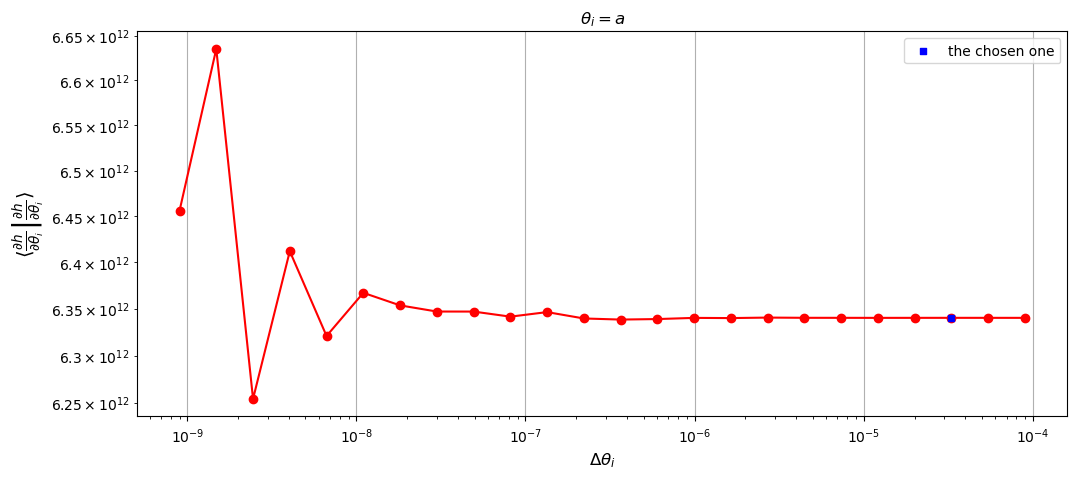

Gamma_ii for p0: 26493260456792.613
Gamma_ii for p0: 26493260492944.816
Gamma_ii for p0: 26493260364478.074
Gamma_ii for p0: 26493260442578.16
Gamma_ii for p0: 26493260629524.58
Gamma_ii for p0: 26493260688254.29
Gamma_ii for p0: 26493260029729.203
Gamma_ii for p0: 26493260871340.62
Gamma_ii for p0: 26493260808126.277
Gamma_ii for p0: 26493260907384.2
Gamma_ii for p0: 26493260236766.83
Gamma_ii for p0: 26493255303778.504
Gamma_ii for p0: 26493261819091.086
Gamma_ii for p0: 26493253144340.758
Gamma_ii for p0: 26493244823328.492
Gamma_ii for p0: 26493262726883.355
Gamma_ii for p0: 26493219169134.832
Gamma_ii for p0: 26493118896004.67
Gamma_ii for p0: 26493318583472.383
Gamma_ii for p0: 26493570031889.133
Gamma_ii for p0: 26493022736138.184
Gamma_ii for p0: 26493081115142.555
Gamma_ii for p0: 26492091329031.445
Gamma_ii for p0: 26490731944317.22
[np.float64(1.3645811218527583e-09), np.float64(4.849034826976111e-09), np.float64(2.94792277857892e-09), np.float64(7.056376358613008e-09), np.f

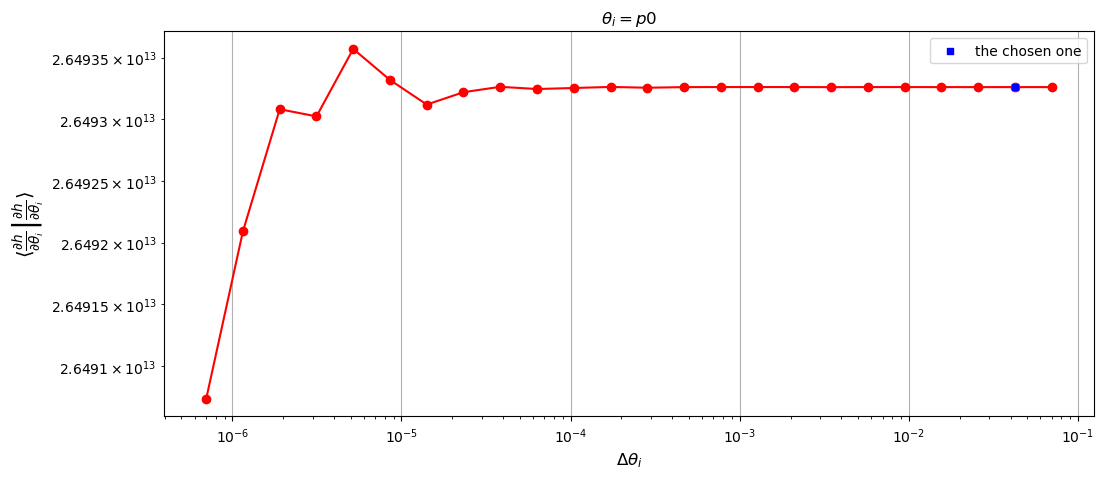

Gamma_ii for e0: 310628426889238.7
Gamma_ii for e0: 310628420057550.3
Gamma_ii for e0: 310628419949064.25
Gamma_ii for e0: 310628419437977.6
Gamma_ii for e0: 310628419837593.25
Gamma_ii for e0: 310628419995731.9
Gamma_ii for e0: 310628421364863.7
Gamma_ii for e0: 310628409308672.56
Gamma_ii for e0: 310628416306137.8
Gamma_ii for e0: 310628477252034.1
Gamma_ii for e0: 310628421273865.2
Gamma_ii for e0: 310628460924462.8
Gamma_ii for e0: 310628493690353.94
Gamma_ii for e0: 310628136207449.9
Gamma_ii for e0: 310628899481575.8
Gamma_ii for e0: 310628398412252.5
Gamma_ii for e0: 310626164220491.9
Gamma_ii for e0: 310629495897384.3
Gamma_ii for e0: 310618207241336.3
Gamma_ii for e0: 310627881710494.2
Gamma_ii for e0: 310630674476945.5
Gamma_ii for e0: 310618190906537.0
Gamma_ii for e0: 310662837158093.2
Gamma_ii for e0: 310659228669550.1
[np.float64(2.1993120828204608e-08), np.float64(3.4924706025864975e-10), np.float64(1.6453311835559442e-09), np.float64(1.286474770109355e-09), np.float64(5

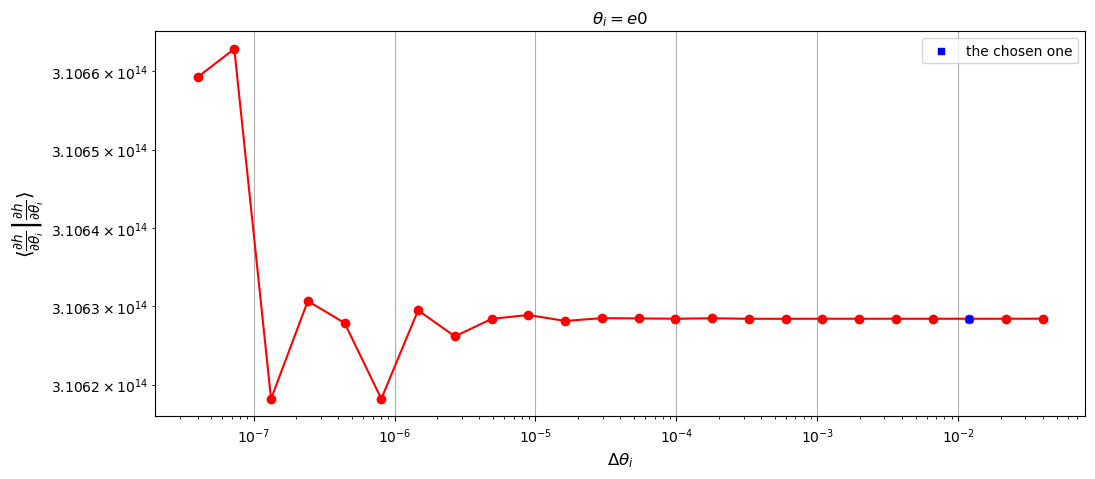

Gamma_ii for qS: 13961.02898021955
Gamma_ii for qS: 13961.028999236354
Gamma_ii for qS: 13961.028999588065
Gamma_ii for qS: 13961.028999594442
Gamma_ii for qS: 13961.028999594691
Gamma_ii for qS: 13961.028999594828
Gamma_ii for qS: 13961.028999594828
Gamma_ii for qS: 13961.028999595175
Gamma_ii for qS: 13961.028999594268
Gamma_ii for qS: 13961.028999594537
Gamma_ii for qS: 13961.02899959485
Gamma_ii for qS: 13961.028999595477
Gamma_ii for qS: 13961.028999595823
Gamma_ii for qS: 13961.028999586717
Gamma_ii for qS: 13961.028999603539
Gamma_ii for qS: 13961.028999603857
Gamma_ii for qS: 13961.028999576703
Gamma_ii for qS: 13961.02899953383
Gamma_ii for qS: 13961.0289996802
Gamma_ii for qS: 13961.028999477674
Gamma_ii for qS: 13961.028999201952
Gamma_ii for qS: 13961.028999755472
Gamma_ii for qS: 13961.029000039025
Gamma_ii for qS: 13961.0289997131
[np.float64(1.3621348971025915e-09), np.float64(2.5192318999766183e-11), np.float64(4.567984816174389e-13), np.float64(1.7849798055216202e-14),

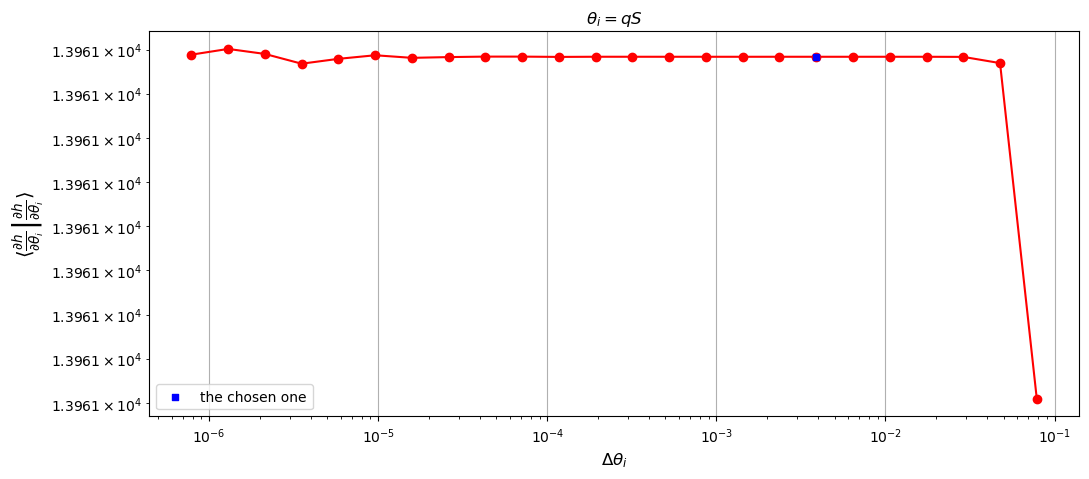

Gamma_ii for phiS: 269693.4332437452
Gamma_ii for phiS: 269693.4332437451
Gamma_ii for phiS: 269693.4332437452
Gamma_ii for phiS: 269693.4332437449
Gamma_ii for phiS: 269693.4332437452
Gamma_ii for phiS: 269693.4332437433
Gamma_ii for phiS: 269693.43324374524
Gamma_ii for phiS: 269693.433243743
Gamma_ii for phiS: 269693.43324374105
Gamma_ii for phiS: 269693.4332437567
Gamma_ii for phiS: 269693.43324375525
Gamma_ii for phiS: 269693.43324371823
Gamma_ii for phiS: 269693.4332437582
Gamma_ii for phiS: 269693.43324369146
Gamma_ii for phiS: 269693.4332437079
Gamma_ii for phiS: 269693.43324355816
Gamma_ii for phiS: 269693.4332438499
Gamma_ii for phiS: 269693.4332438771
Gamma_ii for phiS: 269693.43324437004
Gamma_ii for phiS: 269693.4332439456
Gamma_ii for phiS: 269693.43324279535
Gamma_ii for phiS: 269693.4332500579
Gamma_ii for phiS: 269693.43323701905
Gamma_ii for phiS: 269693.4332211831
[np.float64(2.1582898854218725e-16), np.float64(2.158289885421872e-16), np.float64(1.0791449427109372e-1

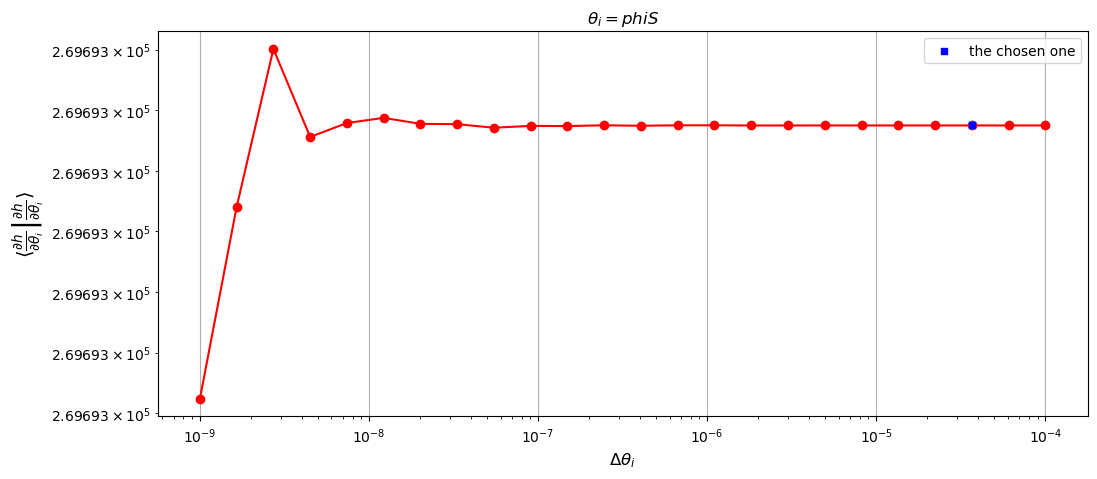

Gamma_ii for dev0p: 466.7173979583081
Gamma_ii for dev0p: 366.07542619276177
Gamma_ii for dev0p: 489.1352405350208
Gamma_ii for dev0p: 608.0248635033211
Gamma_ii for dev0p: 270.615490087011
Gamma_ii for dev0p: 333.9975967061309
Gamma_ii for dev0p: 7500.009756686282
Gamma_ii for dev0p: 4391.639246774072
Gamma_ii for dev0p: 2582.776308143568
Gamma_ii for dev0p: 917.7235597457077
Gamma_ii for dev0p: 91993.00647551616
Gamma_ii for dev0p: 77987.45665021446
Gamma_ii for dev0p: 72783.12773891204
Gamma_ii for dev0p: 80669.71852212338
Gamma_ii for dev0p: 2593288.5492824395
Gamma_ii for dev0p: 13524470.6946277
Gamma_ii for dev0p: 3762680.150490847
Gamma_ii for dev0p: 8561034.141989274
Gamma_ii for dev0p: 86032612.14516735
Gamma_ii for dev0p: 92744944.30783054
Gamma_ii for dev0p: 199498303.1821707
Gamma_ii for dev0p: 312423115.8532463
Gamma_ii for dev0p: 295722963.8694884
Gamma_ii for dev0p: 7511685644.296704
[np.float64(0.2749214084437123), np.float64(0.25158648190560756), np.float64(0.195534146

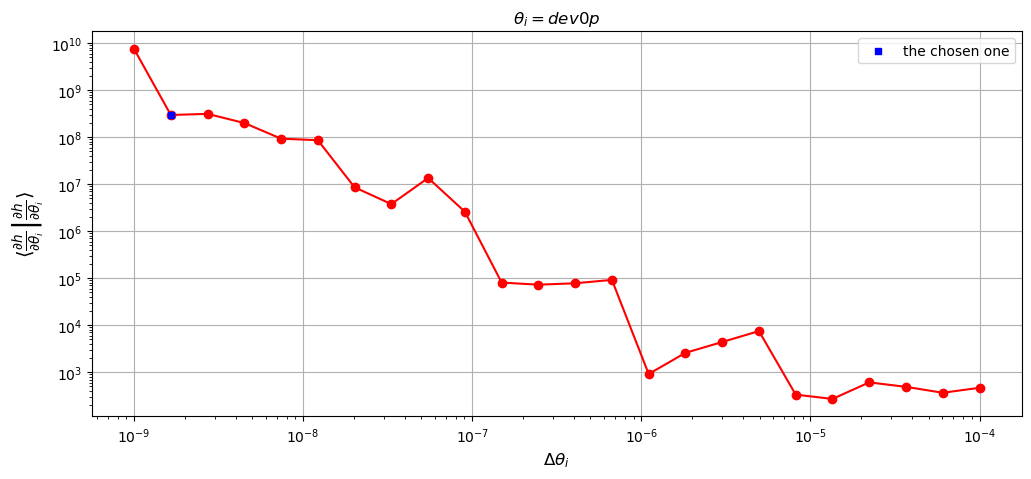

Gamma_ii for dev0e: 40.79406869583035
Gamma_ii for dev0e: 75.60087702264704
Gamma_ii for dev0e: 57.819534158108674
Gamma_ii for dev0e: 44.83651466367346
Gamma_ii for dev0e: 61.38636562714067
Gamma_ii for dev0e: 61.46249471387838
Gamma_ii for dev0e: 141.1000250751209
Gamma_ii for dev0e: 2542.30428558244
Gamma_ii for dev0e: 10591.526984850696
Gamma_ii for dev0e: 13489.564203315093
Gamma_ii for dev0e: 60614.48651996592
Gamma_ii for dev0e: 27272.60129515767
Gamma_ii for dev0e: 458763.65065426135
Gamma_ii for dev0e: 417146.29877661157
Gamma_ii for dev0e: 3522688.3398307115
Gamma_ii for dev0e: 18560971.578337472
Gamma_ii for dev0e: 8896333.583981147
Gamma_ii for dev0e: 14666029.229499398
Gamma_ii for dev0e: 293028912.86659414
Gamma_ii for dev0e: 228231555.66070095
Gamma_ii for dev0e: 359375299.47649974
Gamma_ii for dev0e: 4270299273.2603264
Gamma_ii for dev0e: 1383294183.3087862
Gamma_ii for dev0e: 5568762135.289751
[np.float64(0.46040217650371895), np.float64(0.30753175589265264), np.float6

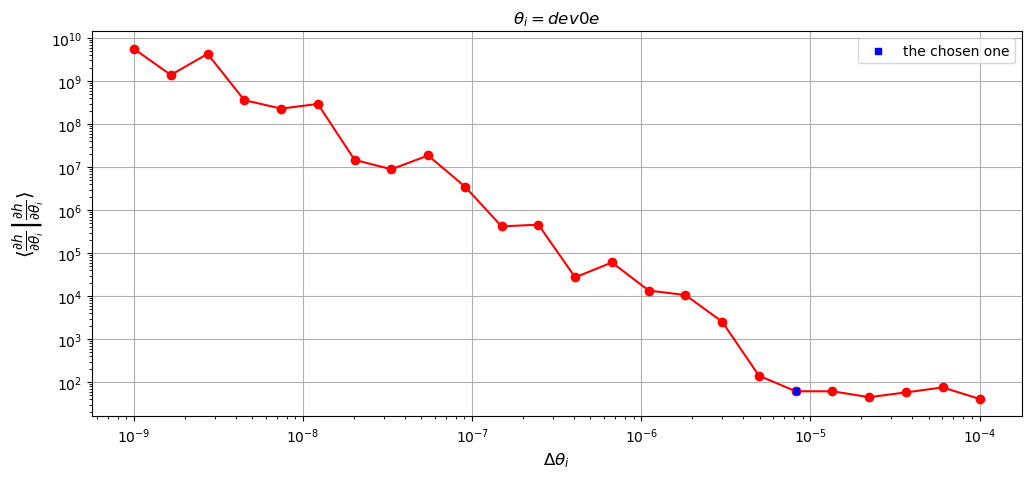

Gamma_ii for dev1p: 0.6395395002482689
Gamma_ii for dev1p: 0.5059488986841946
Gamma_ii for dev1p: 8.514603700957185
Gamma_ii for dev1p: 46.75648874388277
Gamma_ii for dev1p: 41.73620564955904
Gamma_ii for dev1p: 106.03219896205381
Gamma_ii for dev1p: 68.55730158546723
Gamma_ii for dev1p: 119.31242302961344
Gamma_ii for dev1p: 9335.786158210927
Gamma_ii for dev1p: 5247.225246546074
Gamma_ii for dev1p: 27583.547739172813
Gamma_ii for dev1p: 116780.40711974692
Gamma_ii for dev1p: 1037564.6003463023
Gamma_ii for dev1p: 989778.6623451923
Gamma_ii for dev1p: 1953716.3828921644
Gamma_ii for dev1p: 5143760.507325836
Gamma_ii for dev1p: 954217.005021704
Gamma_ii for dev1p: 112965.79012760469
Gamma_ii for dev1p: 176.64923013137664
Gamma_ii for dev1p: 0.004147190248585313
Gamma_ii for dev1p: 0.011285909603303248
Gamma_ii for dev1p: 0.030712783339848327
Gamma_ii for dev1p: 0.0835798879874405
Gamma_ii for dev1p: 0.22744918943668763
[np.float64(0.26403971213594735), np.float64(0.9405786908641072), n

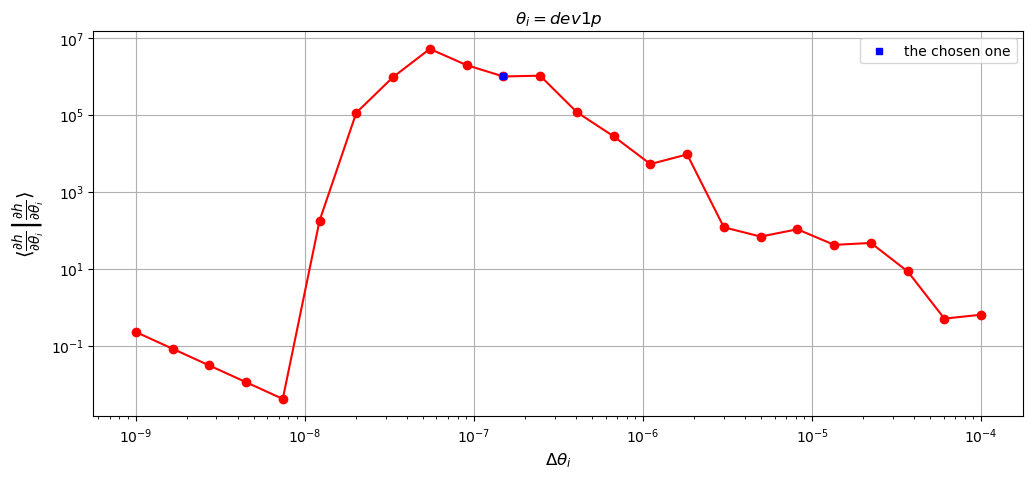

Gamma_ii for dev1e: 1.4984862297557342
Gamma_ii for dev1e: 1.7942698985755798
Gamma_ii for dev1e: 7.945929616395385
Gamma_ii for dev1e: 115.28001916084119
Gamma_ii for dev1e: 81.82013559097422
Gamma_ii for dev1e: 46.04758331031651
Gamma_ii for dev1e: 2194.9924298199594
Gamma_ii for dev1e: 18.156618059129848
Gamma_ii for dev1e: 4782.778574249446
Gamma_ii for dev1e: 99562.05791359289
Gamma_ii for dev1e: 73257.82955432982
Gamma_ii for dev1e: 136561.1746114369
Gamma_ii for dev1e: 328036.8770393105
Gamma_ii for dev1e: 958535.3592405072
Gamma_ii for dev1e: 2595482.645718367
Gamma_ii for dev1e: 6783467.864329676
Gamma_ii for dev1e: 1254952.8273087584
Gamma_ii for dev1e: 148639.06139310467
Gamma_ii for dev1e: 4330.017339646004
Gamma_ii for dev1e: 0.004147190248585313
Gamma_ii for dev1e: 0.011285909603303248
Gamma_ii for dev1e: 0.030712783339848327
Gamma_ii for dev1e: 0.0835798879874405
Gamma_ii for dev1e: 0.22744918943668763
[np.float64(0.16484903918560967), np.float64(0.7741900589110002), np.

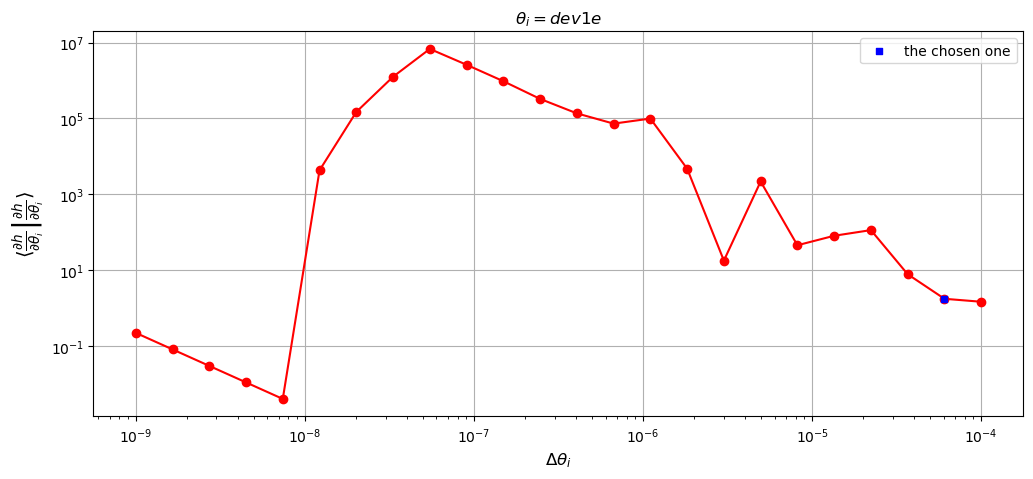

stable deltas: {'m1': 8.185467307069029, 'm2': 0.022275429519995574, 'a': 3.3071957466630214e-05, 'p0': 0.04243329295448302, 'e0': 0.012031530072172399, 'qS': 0.0038971045342728484, 'phiS': 3.674661940736688e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 1.6496480740980207e-09, 'dev0e': 8.185467307069021e-06, 'dev1p': 1.492495545051829e-07, 'dev1e': 6.061898993497572e-05}
Time taken to compute stable deltas is 36567.7387919426 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 83.0050458908081 seconds


In [16]:
der_order = 8
Ndelta = 24
stability_plot = True

delta_range = dict(
    m1 = np.geomspace(1e-4*m1, 1e-9*m1, Ndelta),
    m2 = np.geomspace(1e-2*m2, 1e-7*m2, Ndelta),
    p0 = np.geomspace(1e-2*p0, 1e-7*p0, Ndelta),
    e0 = np.geomspace(1e-1*e0, 1e-7*e0, Ndelta),
    #qS = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiS = np.geomspace(1e-4,    1e-9,    Ndelta),
    qK = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiK = np.geomspace(1e-4,    1e-9,    Ndelta),
    dev_0_p = np.geomspace(1e1,    1e-8,    Ndelta),
    dev_0_e = np.geomspace(1e1,    1e-8,    Ndelta),
    dev_1_p = np.geomspace(1e2,    1e-5,    Ndelta),
    dev_1_e = np.geomspace(1e2,    1e-5,    Ndelta),
)

Fisher = sef(*pars_list,param_names = param_names,T = T, dt = dt, add_param_args=add_param_args,\
             der_order = der_order, Ndelta = Ndelta, stability_plot = stability_plot,
            delta_range = delta_range,
            live_dangerously = False)

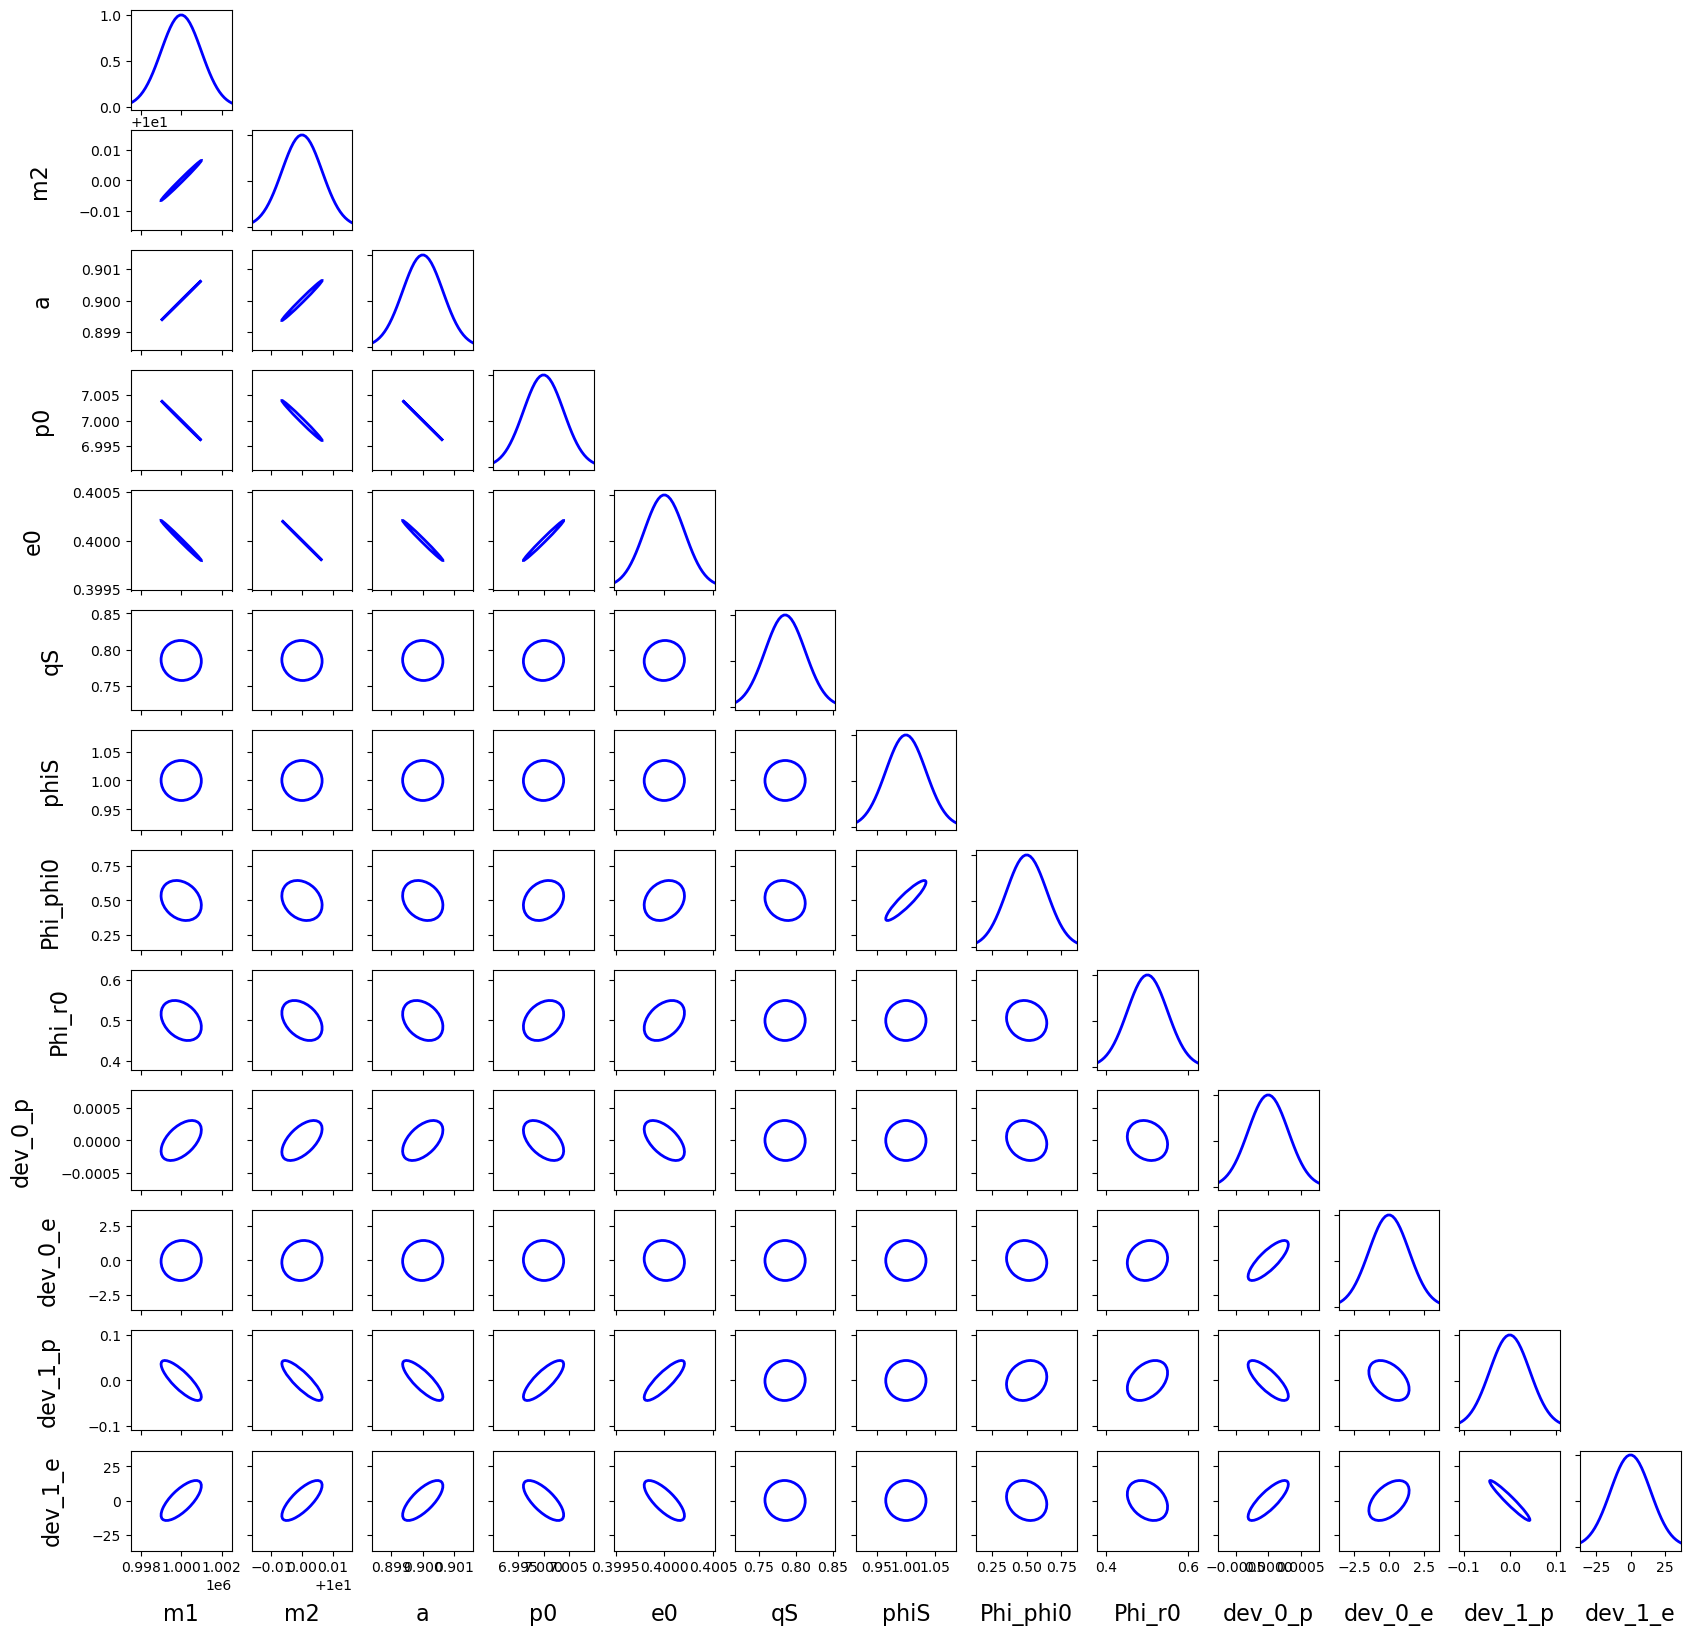

In [17]:

from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = [m1, m2, a,p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_0_p,dev_0_e,dev_1_p,dev_1_e]
param_names = param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',"dev_0_p","dev_0_e","dev_1_p","dev_1_e"] 
wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
param_names = param_names

covariance = np.linalg.inv(Fisher)

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)



In [6]:
pd.DataFrame(np.matmul(Fisher,covariance))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,9.999999e-01,-4.987627e-13,-1.360340e-14,2.966080e-13,1.219595e-14,-6.358625e-14,-6.671663e-15,2.192462e-12,-9.434741e-13,4.334159e-15,3.582818e-13,-2.605379e-12,4.131838e-11
1,9.108107e-04,1.000000e+00,1.664154e-10,4.319270e-09,1.169901e-10,4.029072e-10,2.855579e-10,-2.704755e-08,-1.180443e-08,-1.364475e-10,-1.872442e-08,6.564158e-08,8.177587e-07
2,-4.421553e-03,2.873213e-09,1.000000e+00,3.775115e-08,1.525405e-09,2.650606e-09,4.588627e-10,3.522178e-07,-7.480121e-08,2.588947e-10,1.784669e-07,-1.142348e-07,-5.727086e-05
3,-2.243114e-02,2.134910e-08,-1.556495e-08,1.000000e+00,1.708080e-09,1.891904e-08,-5.572435e-10,6.838612e-07,-1.343675e-07,-1.130383e-09,-2.163503e-07,-1.012063e-07,-2.475258e-04
4,-1.333150e-02,-9.880199e-08,-3.955066e-08,-2.419296e-08,1.000000e+00,-2.984804e-08,-3.479349e-09,1.896270e-06,5.334038e-07,1.690256e-08,-3.015119e-07,-1.029170e-06,-5.842403e-04
5,5.187653e-07,7.144541e-13,1.598751e-13,8.516139e-13,3.936068e-14,1.000000e+00,-4.014453e-15,-7.894524e-12,-2.034937e-12,-3.474245e-14,1.164624e-11,2.042043e-11,1.528506e-09
6,9.094798e-07,-1.181987e-12,8.202379e-14,-4.377514e-12,-3.140388e-13,-5.471354e-13,1.000000e+00,-7.760027e-12,-2.429710e-11,4.612752e-13,-2.339506e-11,-4.332809e-11,6.276703e-10
7,7.827241e-07,-5.654539e-13,2.629319e-13,-1.355234e-12,-1.988817e-14,2.863070e-14,-4.127313e-14,1.000000e+00,-2.872467e-12,-6.028672e-14,6.481407e-12,5.065831e-12,2.251972e-09
8,1.282770e-07,-8.788176e-14,-8.208241e-14,2.501346e-13,-1.576450e-14,1.608189e-13,6.784536e-14,-1.046221e-11,1.000000e+00,-8.901698e-14,-5.981748e-12,-1.274969e-12,-4.674191e-10
9,1.825372e-06,1.144503e-10,-2.345519e-12,-5.684077e-11,-1.313400e-12,-6.089175e-12,-5.279125e-12,-1.577972e-10,-1.993280e-10,1.000000e+00,-6.379238e-10,-7.241360e-10,5.891273e-08


In [7]:
np.linalg.cond(Fisher)

np.float64(2.8326515610185082e+20)

In [8]:
np.sum(np.matmul(Fisher,covariance))

np.float64(12.959842596892244)

In [9]:

pd.DataFrame(Fisher)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,5.892184e+02,-6.489806e+06,4.987221e+07,1.248191e+08,4.251867e+08,-2.327921e+03,1.073747e+04,-2.814401e+03,-2.066824e+03,1.088971e+05,7.516276e+00,2.104120e+04,3.087916e+01
1,-6.489806e+06,7.538247e+10,-6.086281e+11,-1.383971e+12,-4.561413e+12,2.324358e+07,-1.072040e+08,2.809885e+07,1.912203e+07,-6.255813e+08,-5.302751e+05,-2.586525e+08,-3.474532e+05
2,4.987221e+07,-6.086281e+11,6.340235e+12,1.089599e+13,3.421956e+13,-1.888838e+08,8.714886e+08,-2.285579e+08,-8.596660e+07,-3.255443e+09,5.088956e+06,2.369372e+09,2.873481e+06
3,1.248191e+08,-1.383971e+12,1.089599e+13,2.649326e+13,8.979704e+13,-4.919087e+08,2.268958e+09,-5.947379e+08,-4.238394e+08,2.110971e+10,2.275798e+06,4.549146e+09,6.582646e+06
4,4.251867e+08,-4.561413e+12,3.421956e+13,8.979704e+13,3.106289e+14,-1.758005e+09,8.108942e+09,-2.125456e+09,-1.606020e+09,9.679430e+10,-8.741766e+06,1.434814e+10,2.204506e+07
5,-2.327921e+03,2.324358e+07,-1.888838e+08,-4.919087e+08,-1.758005e+09,1.396103e+04,-5.827748e+04,1.527834e+04,1.100670e+04,-7.867707e+05,3.182693e+02,-6.836833e+04,-1.157413e+02
6,1.073747e+04,-1.072040e+08,8.714886e+08,2.268958e+09,8.108942e+09,-5.827748e+04,2.696934e+05,-7.049168e+04,-5.076263e+04,3.629801e+06,-1.469591e+03,3.153526e+05,5.338692e+02
7,-2.814401e+03,2.809885e+07,-2.285579e+08,-5.947379e+08,-2.125456e+09,1.527834e+04,-7.049168e+04,1.848242e+04,1.330030e+04,-9.513320e+05,3.856433e+02,-8.266963e+04,-1.399403e+02
8,-2.066824e+03,1.912203e+07,-8.596660e+07,-4.238394e+08,-1.606020e+09,1.100670e+04,-5.076263e+04,1.330030e+04,1.429713e+04,-1.072205e+06,3.142550e+02,-4.169271e+04,-9.210943e+01
9,1.088971e+05,-6.255813e+08,-3.255443e+09,2.110971e+10,9.679430e+10,-7.867707e+05,3.629801e+06,-9.513320e+05,-1.072205e+06,2.957230e+08,-8.408820e+04,-1.863595e+06,9.885892e+02


In [10]:

pd.DataFrame(covariance)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,993948.680275,6.537977,6.322775e-01,-3.904237e+00,-2.050027e-01,-1.065137e+00,-3.085465e-01,-35.197468,-16.299709,1.635824e-01,62.474004,-35.554354,10687.370650
1,6.537977,0.000043,4.151351e-06,-2.560669e-05,-1.362244e-06,-7.067817e-06,-2.018618e-06,-0.000226,-0.000124,1.192314e-06,0.000957,-0.000244,0.073399
2,0.632278,0.000004,4.023587e-07,-2.484871e-06,-1.301678e-07,-6.764597e-07,-1.971096e-07,-0.000023,-0.000010,1.028470e-07,0.000035,-0.000023,0.006773
3,-3.904237,-0.000026,-2.484871e-06,1.534816e-05,8.029624e-07,4.173748e-06,1.215670e-06,0.000139,0.000061,-6.254415e-07,-0.000170,0.000138,-0.041474
4,-0.205003,-0.000001,-1.301678e-07,8.029624e-07,4.270957e-08,2.215738e-07,6.279620e-08,0.000007,0.000004,-3.679660e-08,-0.000026,0.000008,-0.002299
5,-1.065137,-0.000007,-6.764597e-07,4.173748e-06,2.215738e-07,7.523306e-04,5.711925e-06,-0.000561,0.000018,-1.903535e-07,-0.000129,0.000039,-0.011836
6,-0.308547,-0.000002,-1.971096e-07,1.215670e-06,6.279620e-08,5.711925e-06,1.192203e-03,0.004545,0.000012,-6.874081e-08,-0.000161,0.000012,-0.003672
7,-35.197468,-0.000226,-2.250430e-05,1.394580e-04,7.022180e-06,-5.609727e-04,4.544791e-03,0.020903,-0.000941,-8.267490e-06,-0.023482,0.001210,-0.410737
8,-16.299709,-0.000124,-1.003657e-05,6.093059e-05,3.959996e-06,1.771020e-05,1.205114e-05,-0.000941,0.002404,-3.029903e-06,0.008779,0.000835,-0.231957
9,0.163582,0.000001,1.028470e-07,-6.254415e-07,-3.679660e-08,-1.903535e-07,-6.874081e-08,-0.000008,-0.000003,9.638489e-08,0.000358,-0.000010,0.003690


In [11]:
np.savetxt("../../Results/Covariance_fisher_2th_order_dev_param_unnormalized_no_chi.txt",covariance)

In [ ]:
covariance

array([[ 4.83678044e+05,  3.15948201e+00,  3.10360615e-01,
        -1.90892445e+00, -9.67936872e-02, -5.15008169e-01,
        -1.29598167e-01, -8.67059922e+00, -5.33913682e+00,
         1.50195141e+01,  2.78417490e+00,  2.59016245e+01,
         1.98466306e+00],
       [ 3.15948201e+00,  2.13225697e-05,  2.00878945e-06,
        -1.23486703e-05, -6.55742603e-07, -3.45687638e-06,
        -7.95036998e-07, -3.24635525e-05, -7.03268872e-05,
         3.71018210e-05, -7.65626008e-06,  1.53404440e-04,
         4.80201820e-06],
       [ 3.10360615e-01,  2.00878945e-06,  1.99719791e-07,
        -1.22821252e-06, -6.14519316e-08, -3.27949099e-07,
        -8.39572531e-08, -5.99249863e-06, -2.60389594e-06,
         1.18463012e-05,  2.72172771e-06,  1.73923767e-05,
         1.57673199e-06],
       [-1.90892445e+00, -1.23486703e-05, -1.22821252e-06,
         7.55531462e-06,  3.77850095e-07,  2.01614823e-06,
         5.20620152e-07,  3.83105558e-05,  1.48868552e-05,
        -7.03091365e-05, -1.57169976e

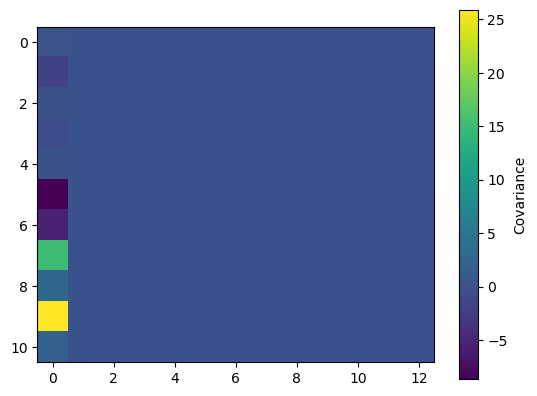

In [ ]:
plt.imshow(covariance[1:][1:], cmap='viridis', interpolation='nearest')
plt.colorbar(label='Covariance')

In [ ]:
import numpy
Covariance_fisher_2th_order_dev_param_unnormalized=np.loadtxt("../../Results/Covariance_fisher_2th_order_dev_param_unnormalized_no_chi.txt")
Covariance_fisher_2th_order_dev_param_normalized=np.loadtxt("../../Results/Covariance_fisher_2th_order_dev_param_normalized_no_chi.txt")

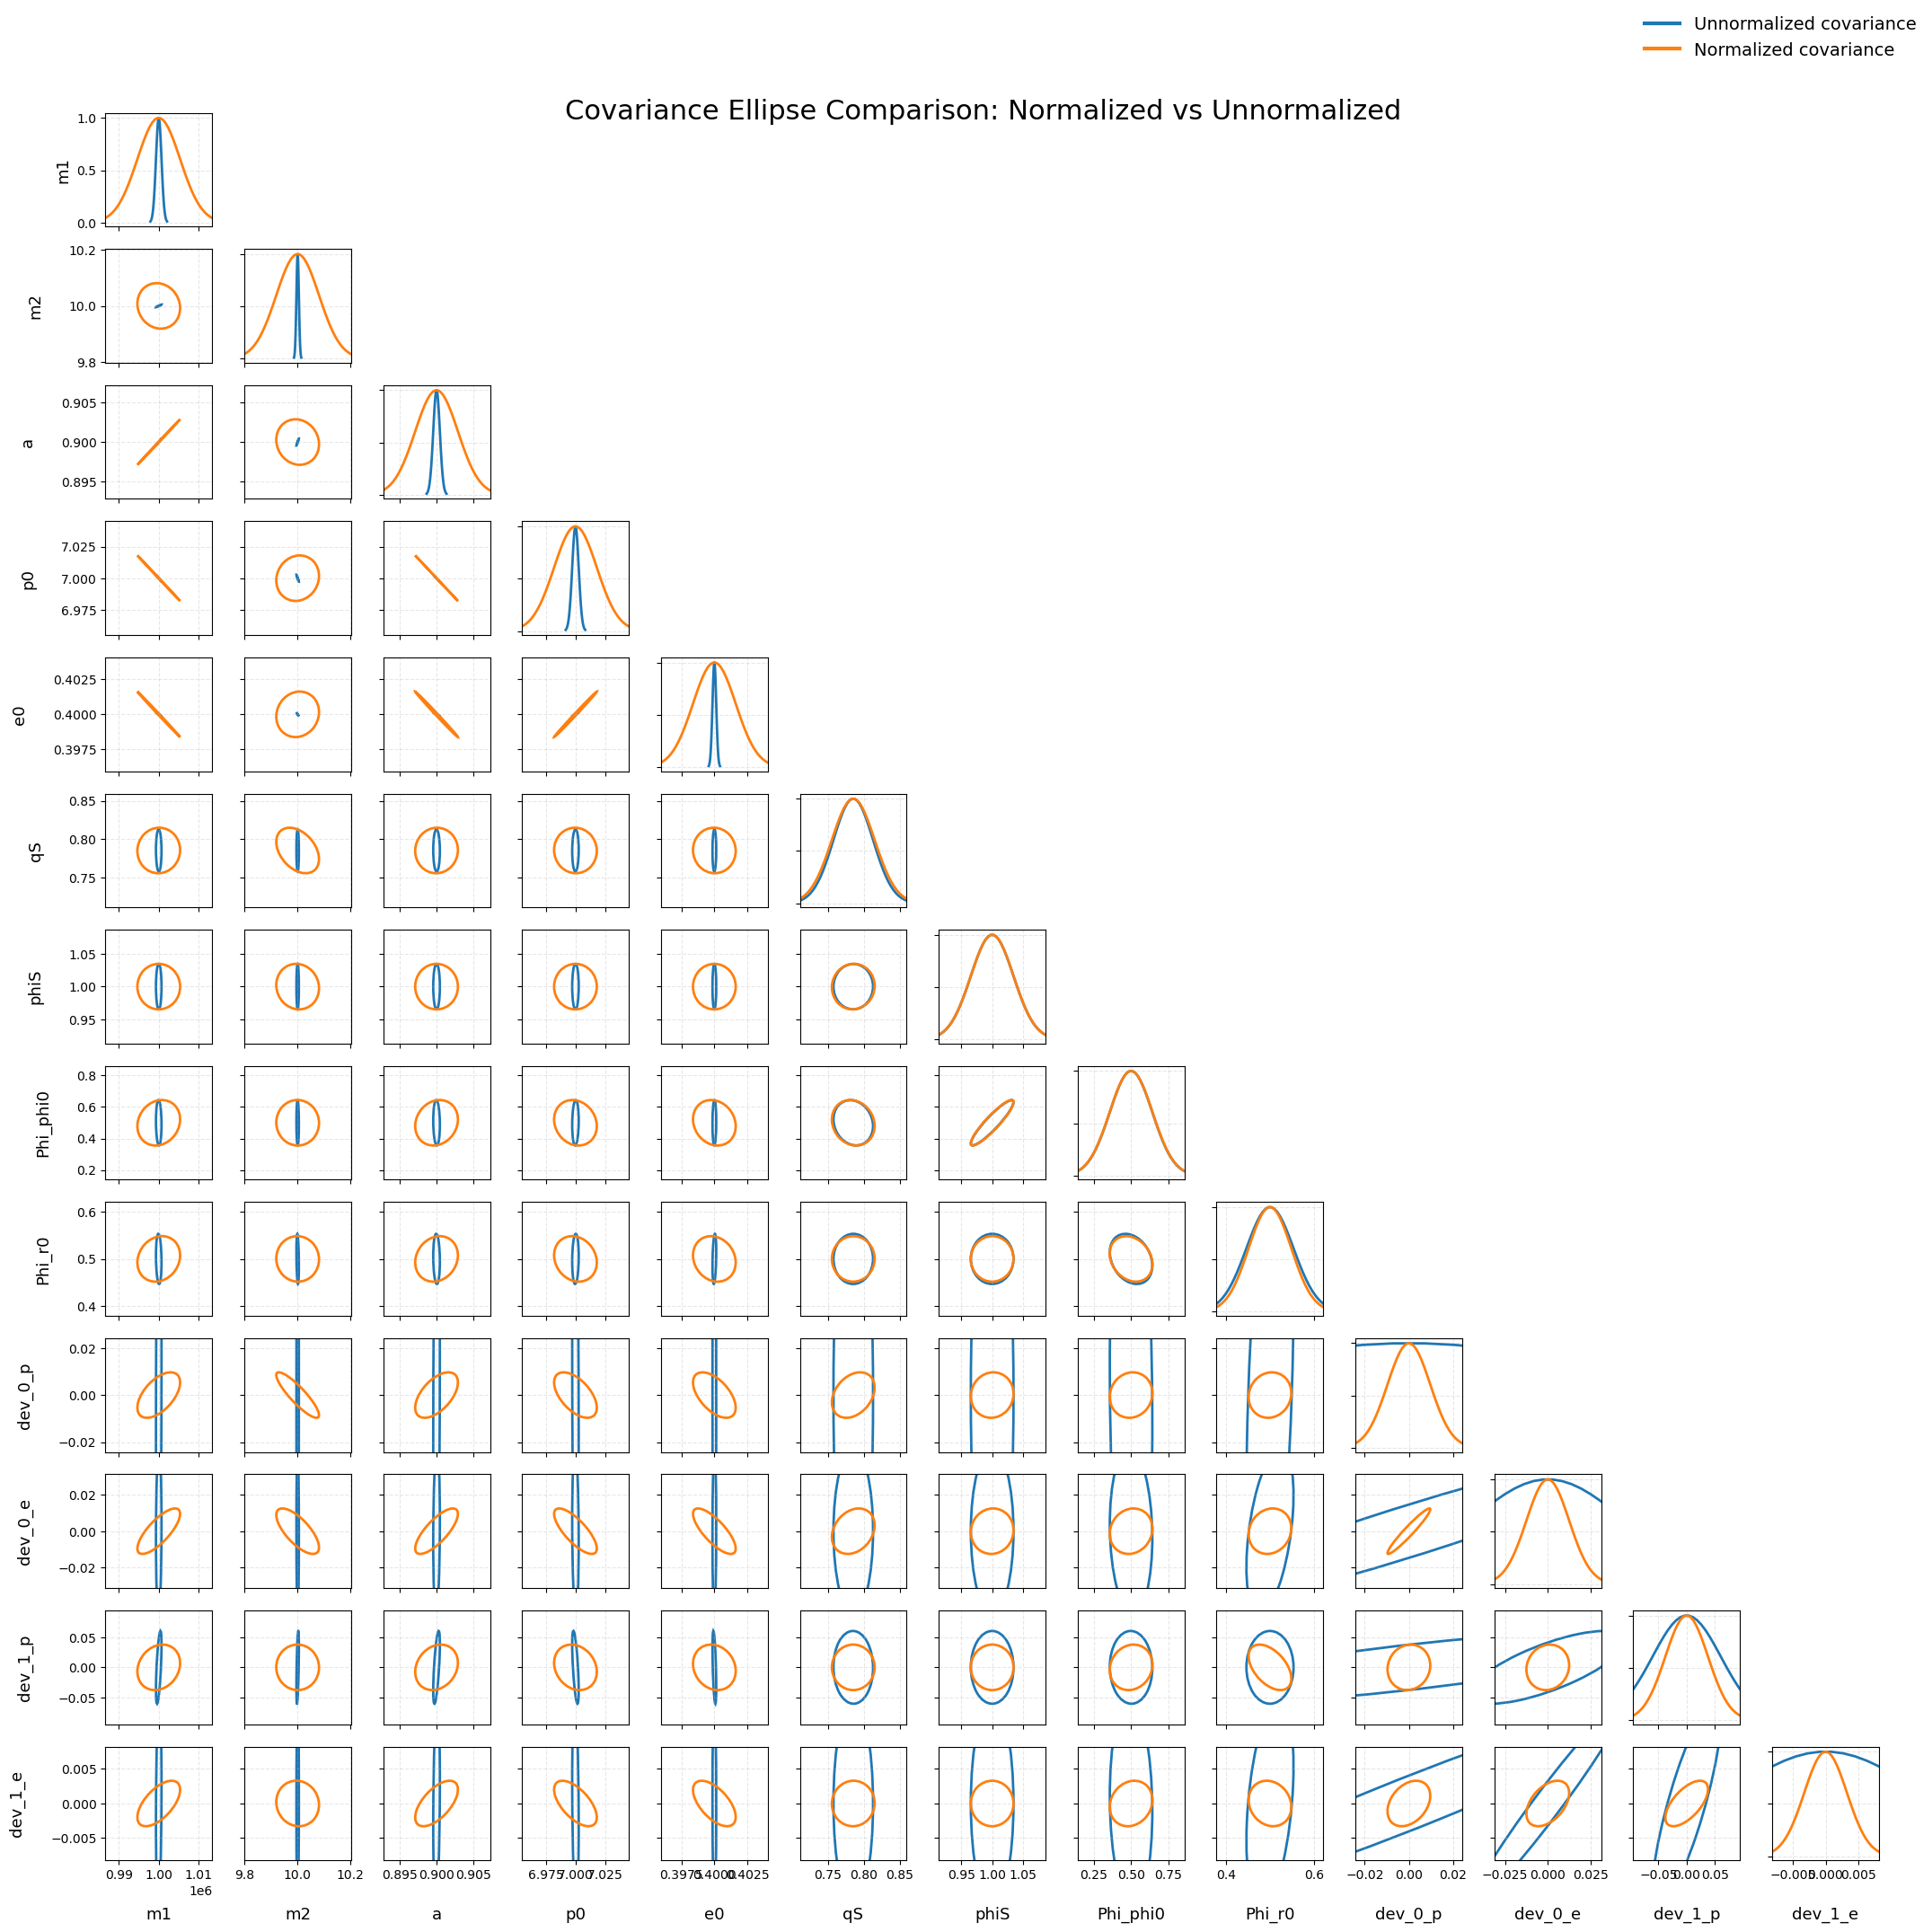

In [19]:
import matplotlib.pyplot as plt
from stableemrifisher.plot import CovEllipsePlot

# Parameters
pars_list = [m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0,
             dev_0_p, dev_0_e, dev_1_p, dev_1_e]
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0',
               "dev_0_p","dev_0_e","dev_1_p","dev_1_e"]

wave_params = {param_names[i]: pars_list[i] for i in range(len(pars_list))}

ellipse_kwargs_unnorm = dict(facecolor='none', edgecolor='tab:blue', lw=2, label='Unnormalized covariance')
line_kwargs_unnorm = dict(lw=2, color='tab:blue')

ellipse_kwargs_norm = dict(facecolor='none', edgecolor='tab:orange', lw=2, label='Normalized covariance')
line_kwargs_norm = dict(lw=2, color='tab:orange')

n_params = len(param_names)
fig, axs = plt.subplots(n_params, n_params, figsize=(22, 22))

fig, axs = CovEllipsePlot(
    Covariance_fisher_2th_order_dev_param_unnormalized,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs_unnorm,
    line_kwargs=line_kwargs_unnorm
)

fig, axs = CovEllipsePlot(
    Covariance_fisher_2th_order_dev_param_normalized,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs_norm,
    line_kwargs=line_kwargs_norm
)

fig.suptitle("Covariance Ellipse Comparison: Normalized vs Unnormalized", fontsize=22, y=0.93)

for i in range(n_params):
    for j in range(n_params):
        axs[i, j].grid(True, linestyle='--', alpha=0.3)
        if i < n_params - 1:
            axs[i, j].set_xlabel('')
        if j > 0:
            axs[i, j].set_ylabel('')

for i, name in enumerate(param_names):
    axs[-1, i].set_xlabel(name, fontsize=13)
    axs[i, 0].set_ylabel(name, fontsize=13)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=3, label='Unnormalized covariance'),
    Line2D([0], [0], color='tab:orange', lw=3, label='Normalized covariance')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.98, 0.98)
)

plt.tight_layout(rect=[0, 0, 0.96, 0.95])
plt.show()
